In [7]:
import pandas as pd
import numpy as np

In [9]:
# Load the dataset
PA_data = pd.read_csv('Ireland House Price Final.csv')
#Preview the datasetprint
print(PA_data.head())

   ID     property_scope   availability       location       size total_sqft  \
0   0  Extended Coverage         17-Oct         Fingal      2 BED       1056   
1   1        Land Parcel  Ready To Move   South Dublin  4 Bedroom       2600   
2   2  Constructed Space  Ready To Move  Dun Laoghaire      3 BED       1440   
3   3  Extended Coverage  Ready To Move   South Dublin      3 BED       1521   
4   4  Extended Coverage  Ready To Move            DCC      2 BED       1200   

   bath  balcony buying or not buying BER Renovation needed  price-per-sqft-$  
0   2.0      1.0                   No   A                No        419.928030  
1   5.0      3.0                   No   D               Yes        523.846154  
2   2.0      3.0                   No   G               Yes        488.680556  
3   3.0      1.0                   No   G               Yes        708.908613  
4   2.0      1.0                   No   F               Yes        482.375000  


In [11]:
#Overview of dataset structureprint
PA_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    13320 non-null  int64  
 1   property_scope        13320 non-null  object 
 2   availability          13320 non-null  object 
 3   location              13319 non-null  object 
 4   size                  13304 non-null  object 
 5   total_sqft            13320 non-null  object 
 6   bath                  13247 non-null  float64
 7   balcony               12711 non-null  float64
 8   buying or not buying  13320 non-null  object 
 9   BER                   13320 non-null  object 
 10  Renovation needed     13320 non-null  object 
 11  price-per-sqft-$      13074 non-null  float64
dtypes: float64(3), int64(1), object(8)
memory usage: 1.2+ MB


In [13]:
#Retrieving the Statistics of the data 
PA_data.describe()

,ID,bath,balcony,price-per-sqft-$
count,13320.000000,13247.000000,12711.000000,1.307400e+04
mean,6659.500000,2.692610,1.584376,1.427913e+03
std,3845.297128,1.341458,0.817263,4.611435e+04
min,0.000000,1.000000,0.000000,3.039868e+01
25%,3329.750000,2.000000,1.000000,4.841873e+02
50%,6659.500000,2.000000,2.000000,6.190909e+02
75%,9989.250000,3.000000,2.000000,8.338172e+02
max,13319.000000,40.000000,3.000000,4.953333e+06


In [15]:
#shape of the datasetprint
print("\nDataset Shape (rows, columns):")
print(PA_data.shape)


Dataset Shape (rows, columns):
(13320, 12)


In [17]:
#categorical columns
print("\nSummary for Categorical Columns:")
print(PA_data.describe(include=['object']))


Summary for Categorical Columns:
           property_scope   availability location   size total_sqft  \
count               13320          13320    13319  13304      13320   
unique                  4             81        5     30       2117   
top     Extended Coverage  Ready To Move   Fingal  2 BED       1200   
freq                 8790          10581     4875   5199        843   

       buying or not buying    BER Renovation needed  
count                 13320  13320             13320  
unique                    2      7                 3  
top                      No      C               Yes  
freq                   9057   1982              7500  


In [19]:
#getting value info
PA_data['property_scope'].value_counts()

property_scope
Extended Coverage    8790
Constructed Space    2418
Land Parcel          2025
Usable Interior        87
Name: count, dtype: int64

In [21]:
#Finding data types 
print("Types of Data:")
print(PA_data.dtypes)

Types of Data:
ID                        int64
property_scope           object
availability             object
location                 object
size                     object
total_sqft               object
bath                    float64
balcony                 float64
buying or not buying     object
BER                      object
Renovation needed        object
price-per-sqft-$        float64
dtype: object


In [23]:
# identifying unique values using catergorical columns 
ctg_columns = PA_data.select_dtypes(include=['object', 'category']).columns
 
#Unique values
print("Unique values")
for column in ctg_columns:
    print(f"{column}:")
    print(PA_data[column].unique())
    print(PA_data[column].unique())

Unique values
property_scope:
['Extended Coverage' 'Land Parcel' 'Constructed Space' 'Usable Interior']
['Extended Coverage' 'Land Parcel' 'Constructed Space' 'Usable Interior']
availability:
['17-Oct' 'Ready To Move' '18-May' '18-Feb' '19-Dec' '18-Nov' '20-Dec'
 '21-Dec' '19-Sep' '20-Sep' '18-Mar' '20-Feb' '18-Apr' '20-Aug' '18-Oct'
 '19-Mar' '17-Sep' '18-Dec' '17-Aug' '19-Apr' '18-Jun' '22-Dec' '22-Jan'
 '18-Aug' '19-Jan' '17-Jul' '18-Jul' '21-Jun' '20-May' '19-Aug' '18-Sep'
 '17-May' '17-Jun' '21-May' '18-Jan' '20-Mar' '17-Dec' '16-Mar' '19-Jun'
 '22-Jun' '19-Jul' '21-Feb' 'Immediate Possession' '19-May' '17-Nov'
 '20-Oct' '20-Jun' '19-Feb' '21-Oct' '21-Jan' '17-Mar' '17-Apr' '22-May'
 '19-Oct' '21-Jul' '21-Nov' '21-Mar' '16-Dec' '22-Mar' '20-Jan' '21-Sep'
 '21-Aug' '14-Nov' '19-Nov' '15-Nov' '16-Jul' '15-Jun' '17-Feb' '20-Nov'
 '20-Jul' '16-Sep' '15-Oct' '15-Dec' '16-Oct' '22-Nov' '15-Aug' '17-Jan'
 '16-Nov' '20-Apr' '16-Jan' '14-Jul']
['17-Oct' 'Ready To Move' '18-May' '18-Feb' '1

In [25]:
#identifying the stats numerical variables 
print("\nBasic Stats for numerical variables:")
print(PA_data.select_dtypes(include=['int64','float64']).describe())


Basic Stats for numerical variables:
                 ID          bath       balcony  price-per-sqft-$
count  13320.000000  13247.000000  12711.000000      1.307400e+04
mean    6659.500000      2.692610      1.584376      1.427913e+03
std     3845.297128      1.341458      0.817263      4.611435e+04
min        0.000000      1.000000      0.000000      3.039868e+01
25%     3329.750000      2.000000      1.000000      4.841873e+02
50%     6659.500000      2.000000      2.000000      6.190909e+02
75%     9989.250000      3.000000      2.000000      8.338172e+02
max    13319.000000     40.000000      3.000000      4.953333e+06


In [27]:
#Intial EDA process 
import seaborn as sns
import matplotlib.pyplot as plt

Text(0, 0.5, 'Frequency')

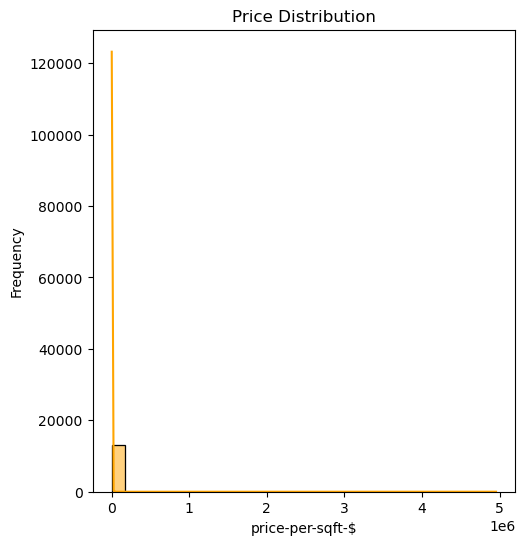

In [28]:
# Plotting histogram and boxplot for price distribution
plt.figure(figsize=(12, 6))
 
# Histogram
plt.subplot(1, 2, 1)
sns.histplot(PA_data['price-per-sqft-$'], bins=30, kde=True, color='Orange')
plt.title('Price Distribution')
plt.xlabel('price-per-sqft-$')
plt.ylabel('Frequency')

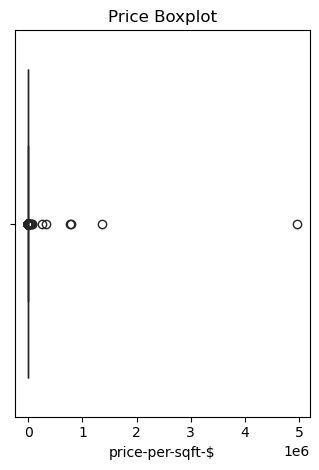

In [29]:
# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=PA_data['price-per-sqft-$'], color='Purple')
plt.title('Price Boxplot')
plt.xlabel('price-per-sqft-$')
 
plt.tight_layout()
plt.show()

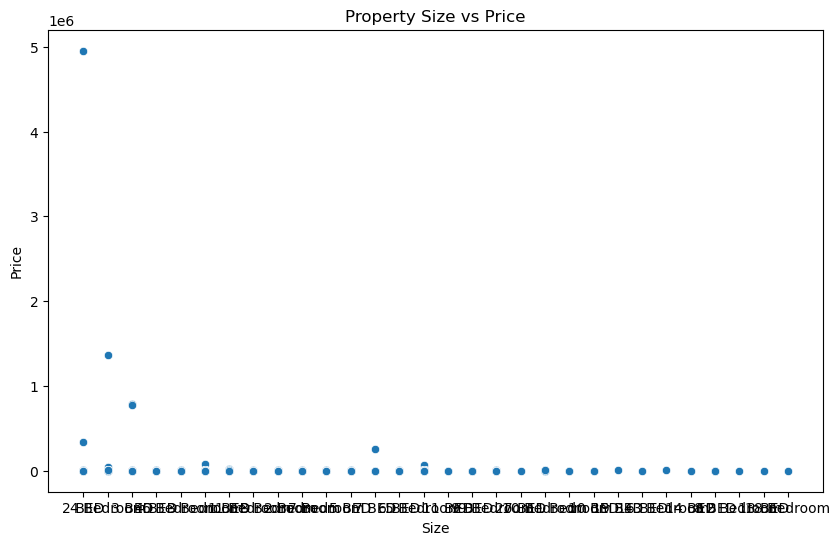

In [30]:
# Scatterplot of size vs. price
plt.figure(figsize=(10, 6))
sns.scatterplot(x=PA_data['size'], y=PA_data['price-per-sqft-$'])
plt.title('Property Size vs Price')
plt.xlabel('Size')
plt.ylabel('Price')
plt.show()

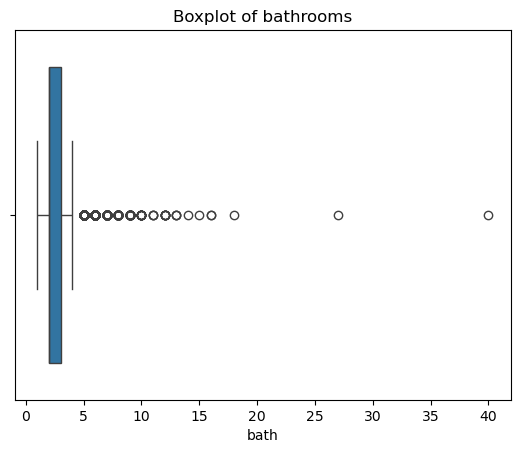

In [32]:
#plot a boxpot for the bath column 
sns.boxplot(x=PA_data['bath'])
plt.title('Boxplot of bathrooms')
plt.show()

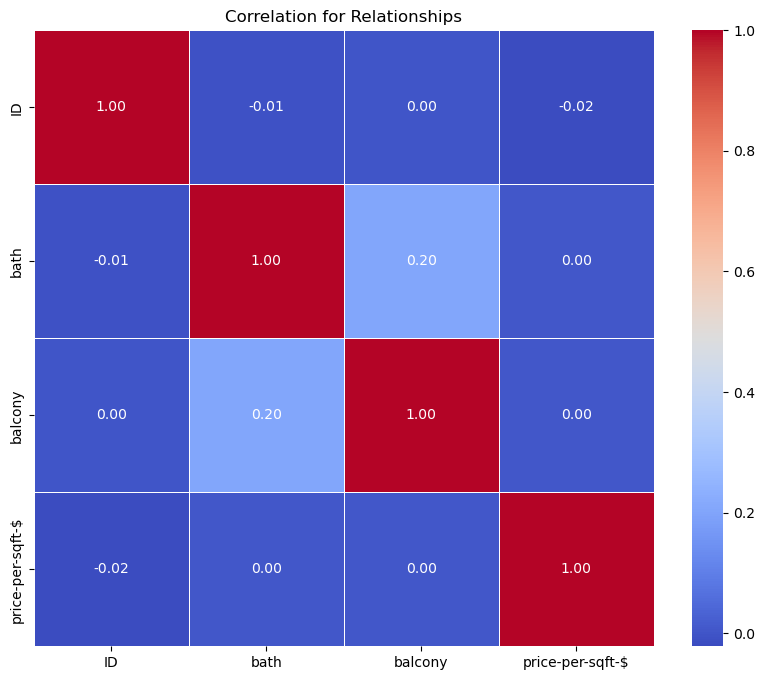

In [33]:
#summary statistics for numerical columns
numerical_columns = PA_data.select_dtypes(include=['int64', 'float64'])
correlation_graph = numerical_columns.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_graph, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation for Relationships')
plt.show()

In [39]:
#finding null values 
PA_data.isnull().sum()

ID                        0
property_scope            0
availability              0
location                  1
size                     16
total_sqft                0
bath                     73
balcony                 609
buying or not buying      0
BER                       0
Renovation needed         0
price-per-sqft-$        246
dtype: int64

In [41]:
#handling missing values in the location column 
#impute location with mode 

most_frequent_location = PA_data['location'].mode()[0]
PA_data['location']= PA_data['location'].fillna(most_frequent_location)
print(PA_data['location'].isnull().sum())

0


In [43]:
#handling Missing values in size 
PA_data['size'] = PA_data['size'].astype(str)
PA_data['numeric_size'] = PA_data['size'].str.extract('(\d+)').astype(float)
print(PA_data[['size', 'numeric_size']].head())

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Hari Prasad\AppData\Local\Temp\ipykernel_34516\1165883858.py:3: SyntaxWarning: invalid escape sequence '\d'
  PA_data['numeric_size'] = PA_data['size'].str.extract('(\d+)').astype(float)


        size  numeric_size
0      2 BED           2.0
1  4 Bedroom           4.0
2      3 BED           3.0
3      3 BED           3.0
4      2 BED           2.0


In [45]:
# calculate  missing value in 'size' with the median
#median of numerical size
median = PA_data['numeric_size'].median()
 
#filling missing values of size with numeric size median
PA_data['numeric_size'] = PA_data['numeric_size'].fillna(median)
 
print("\nSize after filling missing values:")
print(PA_data[['numeric_size']].head())


Size after filling missing values:
   numeric_size
0           2.0
1           4.0
2           3.0
3           3.0
4           2.0


In [47]:
import re

# Extract numeric values from the `size` column
PA_data['numeric_size'] = PA_data['size'].apply(lambda x: float(re.search(r'\d+', x).group()) if re.search(r'\d+', x) else None)

# Verify the cleaned column
print(PA_data[['size', 'numeric_size']].head())

        size  numeric_size
0      2 BED           2.0
1  4 Bedroom           4.0
2      3 BED           3.0
3      3 BED           3.0
4      2 BED           2.0


In [49]:
PA_data['numeric_size'].unique()

array([ 2.,  4.,  3.,  6.,  1.,  8.,  7.,  5., 11.,  9., nan, 27., 10.,
       19., 16., 43., 14., 12., 13., 18.])

In [51]:
PA_data['numeric_size'].isna().sum()

16

In [53]:
PA_data = PA_data.dropna(subset=['numeric_size'])
print(PA_data['numeric_size'].isnull().sum())

0


In [55]:
#Extract numerical average for range entries in `total_sqft`
def convert_sqft_to_num(sqft):
    try:
        if '-' in sqft:
            parts = list(map(float, sqft.split('-')))
            return sum(parts) / 2
        elif 'Sq. Meter' in sqft:
            return float(sqft.split('Sq.')[0]) * 10.764  # Convert to square feet
        elif 'Sq. Yards' in sqft:
            return float(sqft.split('Sq.')[0]) * 9.0  # Convert to square feet
        elif 'Acres' in sqft:
            return float(sqft.split('Acres')[0]) * 43560  # Convert to square feet
        elif 'Perch' in sqft:
            return float(sqft.split('Perch')[0]) * 272.25  # Convert to square feet
        elif 'Guntha' in sqft:
            return float(sqft.split('Guntha')[0]) * 1089  # Convert to square feet
        elif 'Grounds' in sqft:
            return float(sqft.split('Grounds')[0]) * 2400  # Convert to square feet
        else:
            return float(sqft)
    except:
        return None
 
PA_data['total_sqft_cleaned'] = PA_data['total_sqft'].apply(convert_sqft_to_num)

In [57]:
#checking missing values after cleaning 
PA_data.isnull().sum()

ID                        0
property_scope            0
availability              0
location                  0
size                      0
total_sqft                0
bath                     57
balcony                 593
buying or not buying      0
BER                       0
Renovation needed         0
price-per-sqft-$        238
numeric_size              0
total_sqft_cleaned        2
dtype: int64

In [59]:
# Drop rows with null values in total sqft cleaned columns
PA_data.dropna(subset=['total_sqft_cleaned'], inplace=True)

In [61]:
#checking missing values after cleaning 
PA_data.isnull().sum()

ID                        0
property_scope            0
availability              0
location                  0
size                      0
total_sqft                0
bath                     57
balcony                 593
buying or not buying      0
BER                       0
Renovation needed         0
price-per-sqft-$        236
numeric_size              0
total_sqft_cleaned        0
dtype: int64

In [63]:
#filling missing values in balcony with median
median = PA_data['balcony'].median()
PA_data['balcony'] = PA_data['balcony'].fillna(median)
print(PA_data['balcony'].isnull().sum())

0


In [65]:
#filling missing values in bath with median
median = PA_data['bath'].median()
PA_data['bath'] = PA_data['bath'].fillna(median)
print(PA_data['bath'].isnull().sum())

0


In [67]:
#filling missing values in price per sqft $ with median
median = PA_data['price-per-sqft-$'].median()
PA_data['price-per-sqft-$'] = PA_data['price-per-sqft-$'].fillna(median)
print(PA_data['price-per-sqft-$'].isnull().sum())


0


In [69]:
#checking missing values after cleaning 
PA_data.isnull().sum()

ID                      0
property_scope          0
availability            0
location                0
size                    0
total_sqft              0
bath                    0
balcony                 0
buying or not buying    0
BER                     0
Renovation needed       0
price-per-sqft-$        0
numeric_size            0
total_sqft_cleaned      0
dtype: int64

In [71]:
PA_data.to_csv('cleaned_PA_dataset.csv', index=False)
import os
print(os.getcwd())

C:\Users\Hari Prasad


In [73]:
print(PA_data.head())

   ID     property_scope   availability       location       size total_sqft  \
0   0  Extended Coverage         17-Oct         Fingal      2 BED       1056   
1   1        Land Parcel  Ready To Move   South Dublin  4 Bedroom       2600   
2   2  Constructed Space  Ready To Move  Dun Laoghaire      3 BED       1440   
3   3  Extended Coverage  Ready To Move   South Dublin      3 BED       1521   
4   4  Extended Coverage  Ready To Move            DCC      2 BED       1200   

   bath  balcony buying or not buying BER Renovation needed  price-per-sqft-$  \
0   2.0      1.0                   No   A                No        419.928030   
1   5.0      3.0                   No   D               Yes        523.846154   
2   2.0      3.0                   No   G               Yes        488.680556   
3   3.0      1.0                   No   G               Yes        708.908613   
4   2.0      1.0                   No   F               Yes        482.375000   

   numeric_size  total_sqft_clea

In [75]:
PA_data.rename(columns={
    'price-per-sqft-$':'price_per_sqft_$',
    'buying or not buying':'buying_not_buying',
    'Renovation needed':'Renovation_needed'}, inplace=True)

In [77]:
#dropping old size
PA_data.drop(columns=['size'], inplace=True)

#renaming numeric_size to size
PA_data.rename(columns={'numeric_size':'size'}, inplace=True)
print(PA_data.columns)

Index(['ID', 'property_scope', 'availability', 'location', 'total_sqft',
       'bath', 'balcony', 'buying_not_buying', 'BER', 'Renovation_needed',
       'price_per_sqft_$', 'size', 'total_sqft_cleaned'],
      dtype='object')


In [79]:
#feature engineering 
# Encode categorical variables using one-hot encoding or label encoding
cat_columns = ['property_scope', 'availability', 'location', 'BER', 'Renovation_needed']
PA_data_encoded = pd.get_dummies(PA_data, columns=cat_columns, drop_first=True)

bool_columns = PA_data_encoded.select_dtypes(include=['bool']).columns
PA_data_encoded[bool_columns] = PA_data_encoded[bool_columns].astype(int)
# Verifying the encoded dataset structure
PA_data_encoded.head(), PA_data_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13302 entries, 0 to 13319
Columns: 102 entries, ID to Renovation_needed_Yes
dtypes: float64(5), int32(94), int64(1), object(2)
memory usage: 5.7+ MB


(   ID total_sqft  bath  balcony buying_not_buying  price_per_sqft_$  size  \
 0   0       1056   2.0      1.0                No        419.928030   2.0   
 1   1       2600   5.0      3.0                No        523.846154   4.0   
 2   2       1440   2.0      3.0                No        488.680556   3.0   
 3   3       1521   3.0      1.0                No        708.908613   3.0   
 4   4       1200   2.0      1.0                No        482.375000   2.0   
 
    total_sqft_cleaned  property_scope_Extended Coverage  \
 0              1056.0                                 1   
 1              2600.0                                 0   
 2              1440.0                                 0   
 3              1521.0                                 1   
 4              1200.0                                 1   
 
    property_scope_Land Parcel  ...  location_Other  location_South Dublin  \
 0                           0  ...               0                      0   
 1          

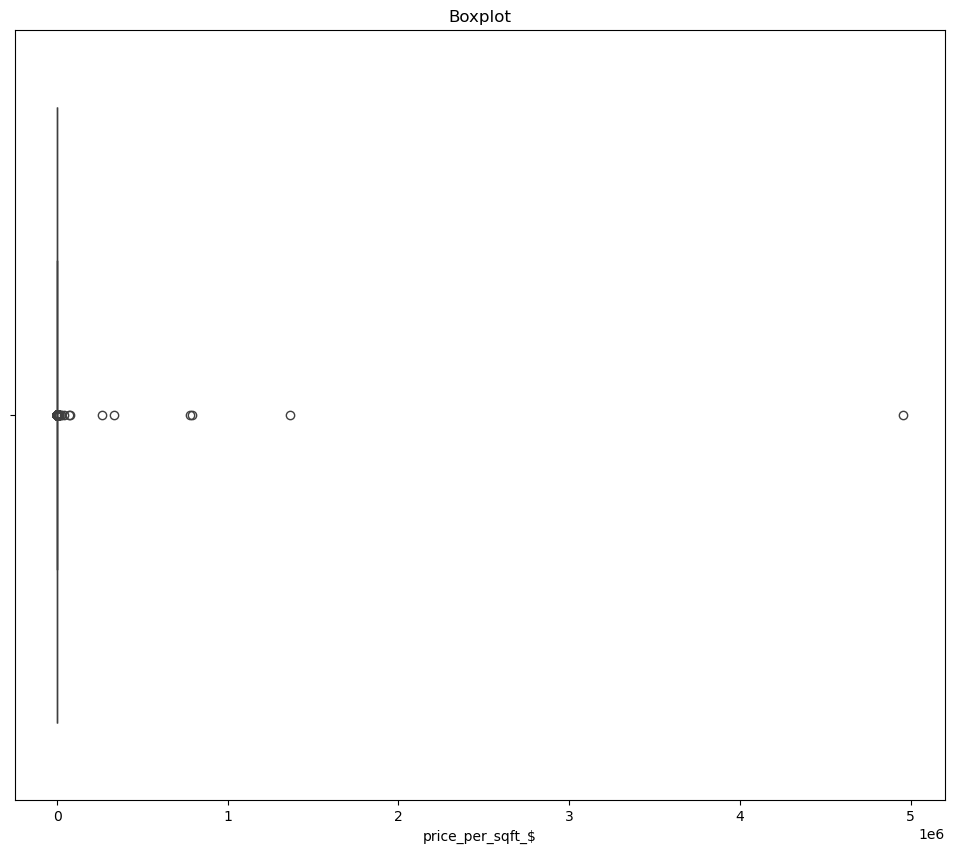

In [81]:
#Handling Missing values 
# Boxplot checking for outlier handling

plt.figure(figsize=(12, 10))
sns.boxplot(x=PA_data['price_per_sqft_$'])
plt.title("Boxplot")
plt.show()

In [83]:
# Cap/Floor approach for 'price-per-sqft-$'
Q1 = PA_data['price_per_sqft_$'].quantile(0.25)
Q3 = PA_data['price_per_sqft_$'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
 
# Capping the outliers
PA_data['price_per_sqft_$'] = np.where(
    PA_data['price_per_sqft_$'] < lower_bound, lower_bound,
    np.where(PA_data['price_per_sqft_$'] > upper_bound, upper_bound, PA_data['price_per_sqft_$'])
)

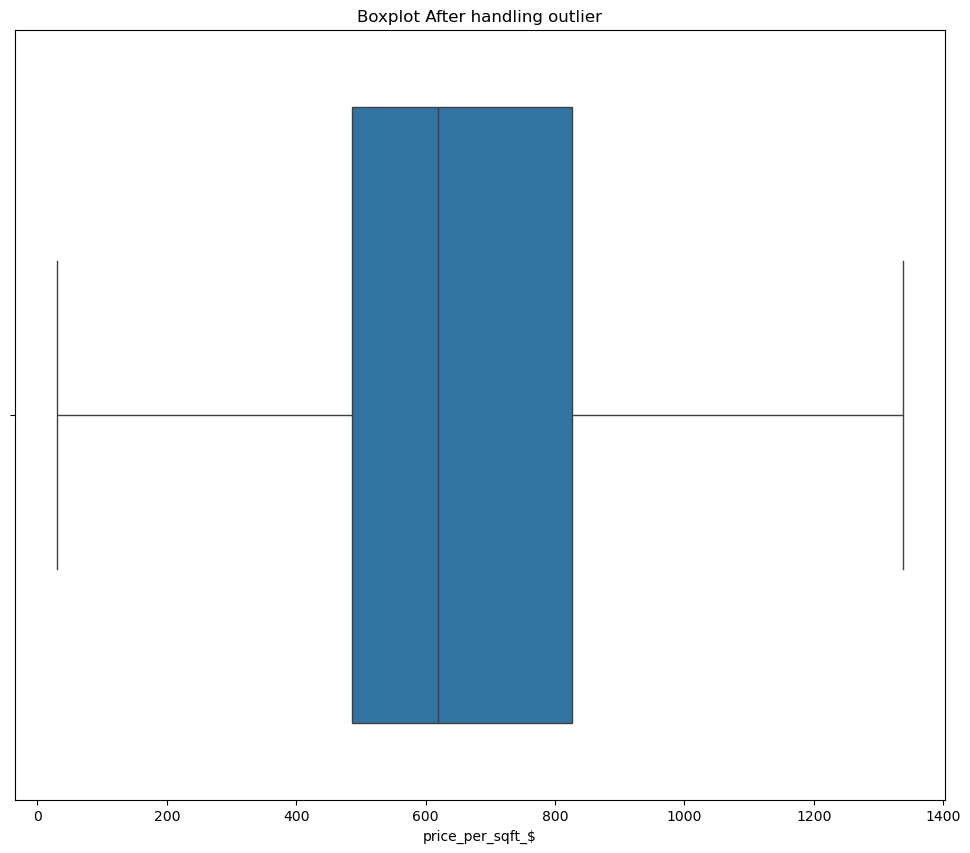

In [85]:
#Handling Missing values 
# Boxplot checking After outlier handling

plt.figure(figsize=(12, 10))
sns.boxplot(x=PA_data['price_per_sqft_$'])
plt.title("Boxplot After handling outlier")
plt.show()

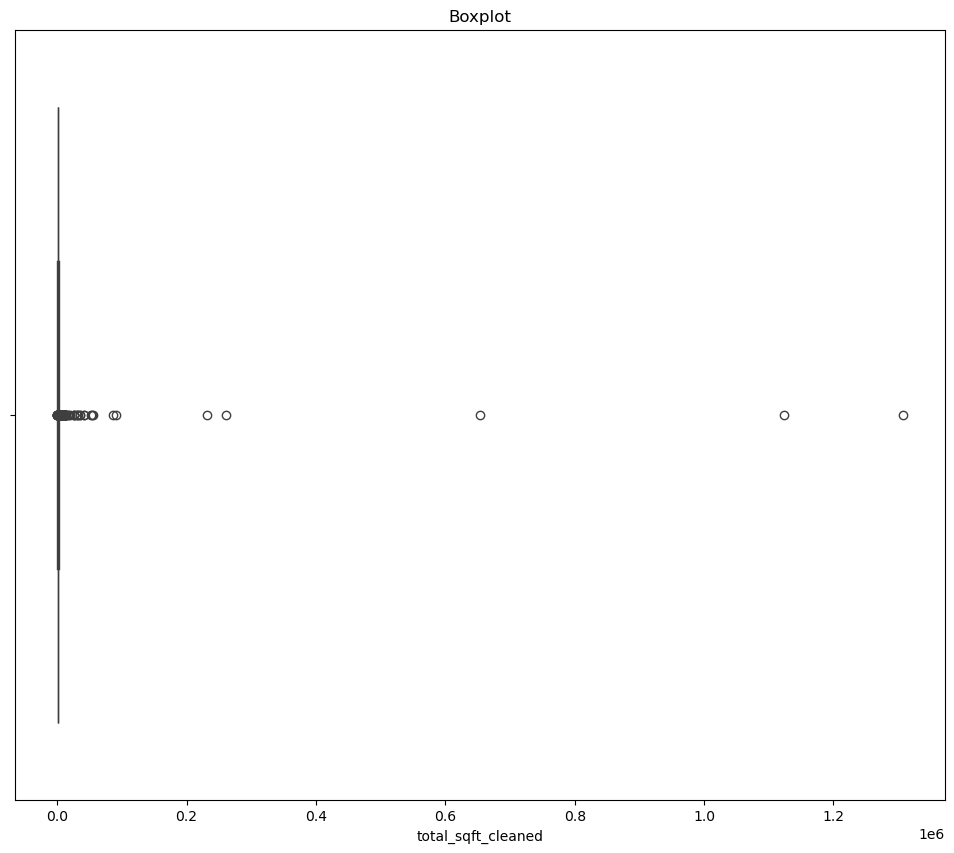

In [87]:
#Handling Missing values 
# Boxplot checking for outlier handling

plt.figure(figsize=(12, 10))
sns.boxplot(x=PA_data['total_sqft_cleaned'])
plt.title("Boxplot")
plt.show()

In [89]:
# Cap/Floor approach for 'price-per-sqft-$'
Q1 = PA_data['total_sqft_cleaned'].quantile(0.25)
Q3 = PA_data['total_sqft_cleaned'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
 
# Capping the outliers
PA_data['total_sqft_cleaned'] = np.where(
    PA_data['total_sqft_cleaned'] < lower_bound, lower_bound,
    np.where(PA_data['total_sqft_cleaned'] > upper_bound, upper_bound, PA_data['total_sqft_cleaned'])
)

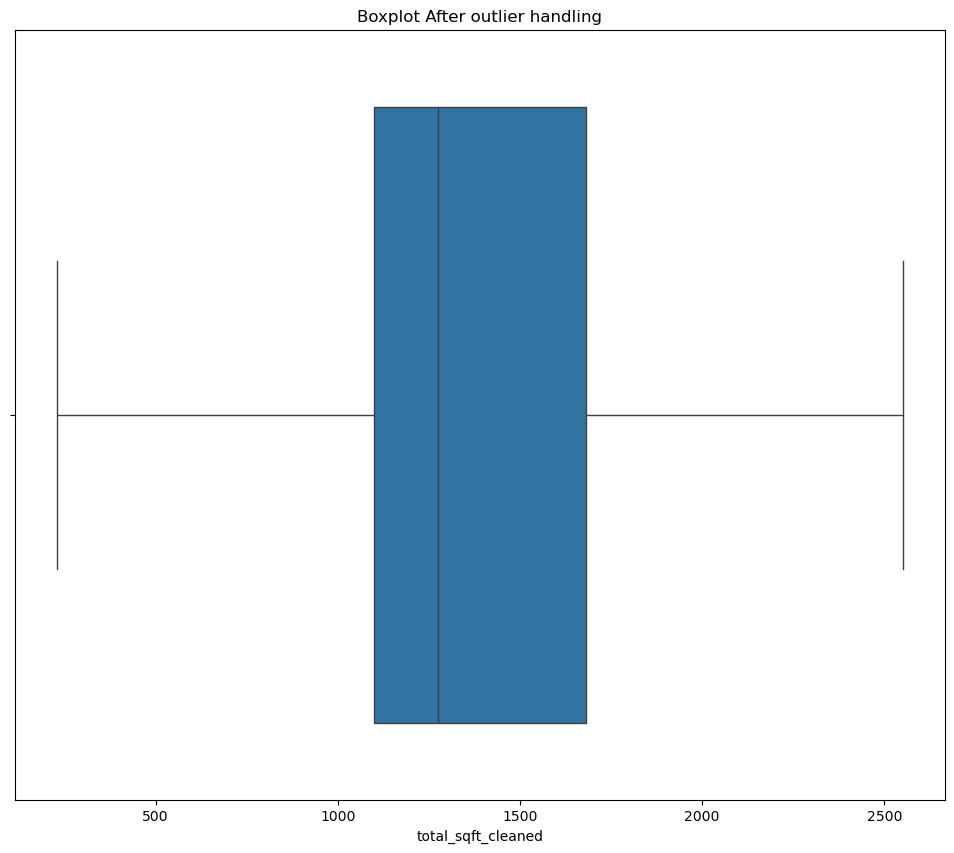

In [91]:
#Handling Missing values 
# Boxplot checking After outlier handling
plt.figure(figsize=(12, 10))
sns.boxplot(x=PA_data['total_sqft_cleaned'])
plt.title("Boxplot After outlier handling")
plt.show()

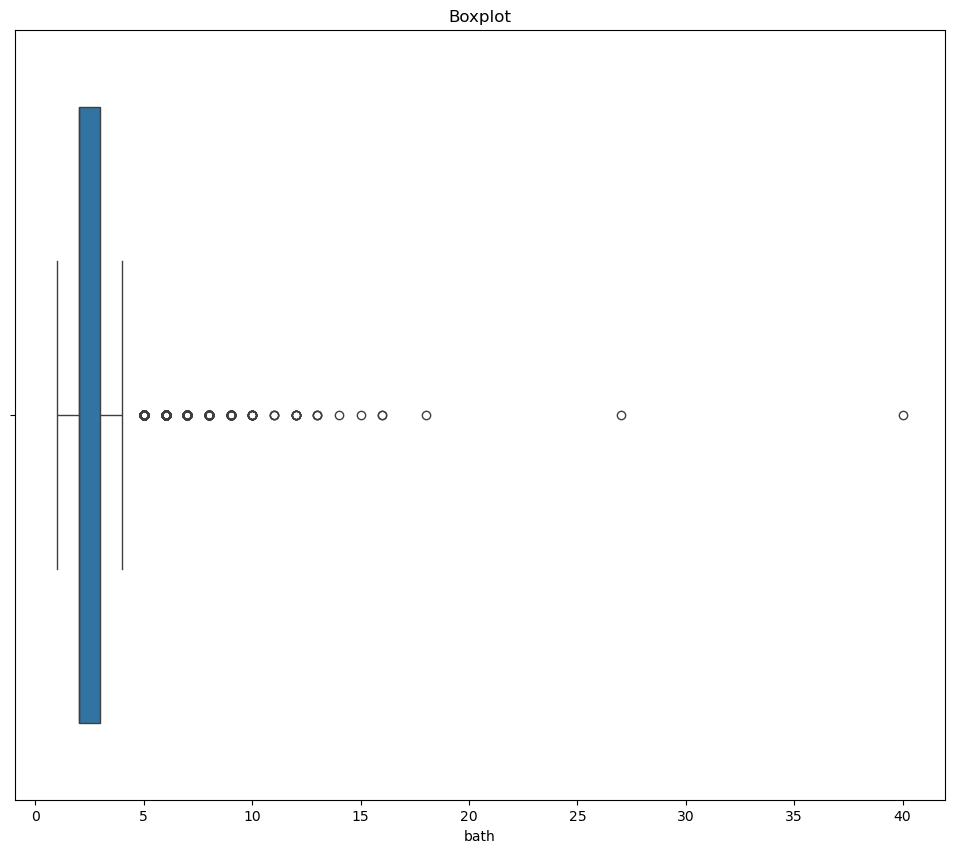

In [93]:
#Handling Missing values 
# Boxplot checking for outlier handling

plt.figure(figsize=(12, 10))
sns.boxplot(x=PA_data['bath'])
plt.title("Boxplot")
plt.show()

In [95]:
# Cap/Floor approach for 'price-per-sqft-$'
Q1 = PA_data['bath'].quantile(0.25)
Q3 = PA_data['bath'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
 
# Capping the outliers
PA_data['bath'] = np.where(
    PA_data['bath'] < lower_bound, lower_bound,
    np.where(PA_data['bath'] > upper_bound, upper_bound, PA_data['bath'])
)

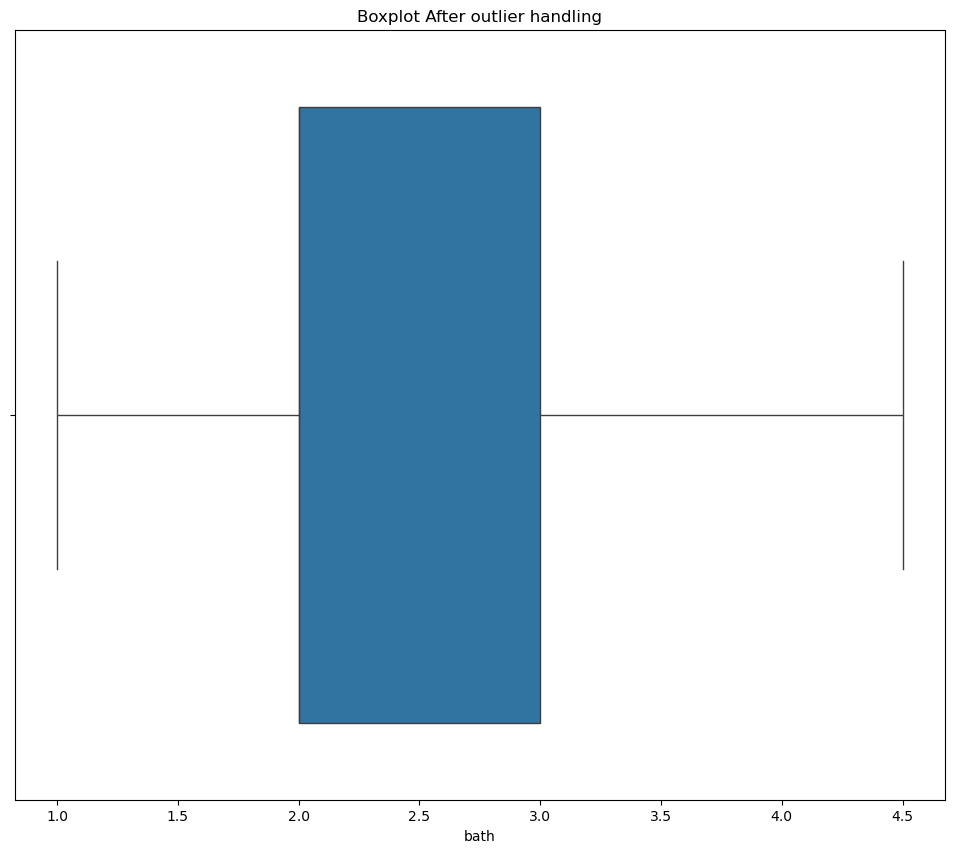

In [97]:
#Handling Missing values 
# Boxplot checking After outlier handling

plt.figure(figsize=(12, 10))
sns.boxplot(x=PA_data['bath'])
plt.title("Boxplot After outlier handling")
plt.show()

In [99]:
# Convert target variable to binary (0 for 'No', 1 for 'Yes')
PA_data_encoded['target'] = PA_data['buying_not_buying'].apply(lambda x: 1 if x == 'Yes' else 0)


In [101]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Splitting the data into features (X) and target (y)
X = PA_data_encoded.drop(columns=['ID', 'buying_not_buying', 'total_sqft', 'target'])
y = PA_data_encoded['target']

# Train-test split (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Check for remaining NaN values in the dataset
remaining_missing = X.isnull().sum().sum()

# Impute missing values (if any) using appropriate methods (e.g., filling with median for numerical)
X.fillna(X.median(), inplace=True)

# Recheck for missing values after imputation
post_imputation_missing = X.isnull().sum().sum()

remaining_missing, post_imputation_missing

(0, 0)

In [104]:
import numpy as np

# Extract feature importance from the trained Random Forest model
feature_importances = rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for feature importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Display the top 10 most important features
top_features = importance_df.head(10)
top_features

,Feature,Importance
2,price_per_sqft_$,0.280160
4,total_sqft_cleaned,0.250953
1,balcony,0.054022
87,location_Dun Laoghaire,0.053403
0,bath,0.047176
3,size,0.047111
97,Renovation_needed_No,0.031831
90,location_South Dublin,0.028971
88,location_Fingal,0.022306
98,Renovation_needed_Yes,0.017538


In [103]:
# Re-initialize the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
# Train a Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000, random_state=42)


# Re-train Logistic Regression and Random Forest models
logistic_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# Generate predictions and evaluate the models
logistic_predictions = logistic_model.predict(X_test)
rf_predictions = rf_model.predict(X_test)

logistic_report = classification_report(y_test, logistic_predictions)
rf_report = classification_report(y_test, rf_predictions)

# Calculate accuracy scores
logistic_accuracy = accuracy_score(y_test, logistic_predictions)
rf_accuracy = accuracy_score(y_test, rf_predictions)

print(logistic_accuracy)
print(rf_accuracy)
print(logistic_report)
print(rf_report)

D:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.7512213453588876
0.7095077038707253
              precision    recall  f1-score   support

           0       0.73      1.00      0.84      1809
           1       0.97      0.23      0.37       852

    accuracy                           0.75      2661
   macro avg       0.85      0.61      0.61      2661
weighted avg       0.81      0.75      0.69      2661

              precision    recall  f1-score   support

           0       0.73      0.91      0.81      1809
           1       0.60      0.29      0.39       852

    accuracy                           0.71      2661
   macro avg       0.66      0.60      0.60      2661
weighted avg       0.69      0.71      0.67      2661



In [105]:
# Select the top 10 features based on importance
selected_features = top_features['Feature'].tolist()

# Refine the training and testing sets to include only these features
X_train_refined = X_train[selected_features]
X_test_refined = X_test[selected_features]

# Re-train the Random Forest model with the refined feature set
rf_model_refined = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_refined.fit(X_train_refined, y_train)

# Evaluate the refined model
rf_predictions_refined = rf_model_refined.predict(X_test_refined)
rf_accuracy_refined = accuracy_score(y_test, rf_predictions_refined)
rf_report_refined = classification_report(y_test, rf_predictions_refined)

print("Random Forest model with the refined feature set Accuracy :",rf_accuracy_refined)
print("Random Forest model with the refined feature set Report\n",rf_report_refined)


Random Forest model with the refined feature set Accuracy : 0.6760616309658023
Random Forest model with the refined feature set Report
               precision    recall  f1-score   support

           0       0.72      0.86      0.78      1809
           1       0.49      0.29      0.37       852

    accuracy                           0.68      2661
   macro avg       0.61      0.57      0.57      2661
weighted avg       0.65      0.68      0.65      2661



In [106]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid for tuning
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the Random Forest model
rf_tuned = RandomForestClassifier(random_state=42)

# Perform GridSearchCV
grid_search = GridSearchCV(estimator=rf_tuned, param_grid=param_grid, cv=3, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_train_refined, y_train)

# Best parameters and model
best_params = grid_search.best_params_
best_rf_model = grid_search.best_estimator_

# Evaluate the tuned model
tuned_predictions = best_rf_model.predict(X_test_refined)
tuned_accuracy = accuracy_score(y_test, tuned_predictions)
tuned_report = classification_report(y_test, tuned_predictions)

print("Best Parameters:", best_params)
print("Tuned Model Accuracy:", tuned_accuracy)
print("Classification Report:\n", tuned_report)


Best Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Tuned Model Accuracy: 0.7376925967681323
Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.97      0.83      1809
           1       0.80      0.24      0.37       852

    accuracy                           0.74      2661
   macro avg       0.76      0.61      0.60      2661
weighted avg       0.75      0.74      0.69      2661



In [107]:
# Predictions and evaluation
tuned_predictions = best_rf_model.predict(X_test_refined)
tuned_accuracy = accuracy_score(y_test, tuned_predictions)
tuned_report = classification_report(y_test, tuned_predictions)

print("Best Parameters:", best_params)
print("Tuned Model Accuracy:", tuned_accuracy)
print("Classification Report:\n", tuned_report)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Tuned Model Accuracy: 0.7376925967681323
Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.97      0.83      1809
           1       0.80      0.24      0.37       852

    accuracy                           0.74      2661
   macro avg       0.76      0.61      0.60      2661
weighted avg       0.75      0.74      0.69      2661



In [125]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define the parameter grid for Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],  # Regularization strength
    'solver': ['liblinear', 'newton-cg', 'saga'],  # Solver choice
    'max_iter': [100, 200, 500],  # Maximum number of iterations
    'penalty': ['l2', 'l1']  # Regularization type
}

# Initialize Logistic Regression model
log_model = LogisticRegression(random_state=42)

# Perform GridSearchCV
grid_search_lr = GridSearchCV(estimator=log_model, param_grid=param_grid_lr, cv=5, n_jobs=-1, scoring='accuracy')
grid_search_lr.fit(X_train, y_train)

# Best parameters and model
best_lr_params = grid_search_lr.best_params_
best_log_model = grid_search_lr.best_estimator_

# Evaluate the tuned model on the test set
log_predictions_tuned = best_log_model.predict(X_test)
tuned_log_accuracy = accuracy_score(y_test, log_predictions_tuned)
tuned_log_report = classification_report(y_test, log_predictions_tuned)

# Print results
print("Best Logistic Regression Parameters:", best_lr_params)
print("Tuned Logistic Regression Accuracy:", tuned_log_accuracy)
print("Tuned Logistic Regression Classification Report:\n", tuned_log_report)


D:\Anaconda\Lib\site-packages\sklearn\model_selection\_validation.py:547: FitFailedWarning: 
75 fits failed out of a total of 450.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
75 fits failed with the following error:
Traceback (most recent call last):
  File "D:\Anaconda\Lib\site-packages\sklearn\model_selection\_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "D:\Anaconda\Lib\site-packages\sklearn\base.py", line 1474, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1172, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)


Best Logistic Regression Parameters: {'C': 0.1, 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Tuned Logistic Regression Accuracy: 0.7519729425028185
Tuned Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.73      1.00      0.85      1809
           1       0.99      0.23      0.37       852

    accuracy                           0.75      2661
   macro avg       0.86      0.61      0.61      2661
weighted avg       0.82      0.75      0.69      2661



In [135]:
from sklearn.metrics import accuracy_score

# 1. Compare  Test Accuracy (if applicable)
# Accuracy of untuned model (before tuning)
untuned_rf = RandomForestClassifier(random_state=42)  # Untuned model
untuned_rf.fit(X_train, y_train)
y_pred_rf_untuned = untuned_rf.predict(X_test)
untuned_rf_accuracy = accuracy_score(y_test, y_pred_rf_untuned)

# Accuracy of tuned Random Forest model (after GridSearchCV)
y_pred_rf_tuned = best_rf_model.predict(X_test_refined)  # Best model from GridSearchCV
tuned_rf_accuracy = accuracy_score(y_test, y_pred_rf_tuned)

# Print the accuracy comparison for Random Forest
print(f"Untuned Random Forest Accuracy: {untuned_rf_accuracy}")
print(f"Tuned Random Forest Accuracy: {tuned_rf_accuracy}")

# 2. Compare Logistic Regression Accuracy (untuned)
# 1. Accuracy of Untuned Logistic Regression
untuned_log_model = LogisticRegression(max_iter=1000, random_state=42)
untuned_log_model.fit(X_train, y_train)
y_pred_log_untuned = untuned_log_model.predict(X_test)
untuned_log_accuracy = accuracy_score(y_test, y_pred_log_untuned)

# 2. Accuracy of Tuned Logistic Regression
y_pred_log_tuned = best_log_model.predict(X_test)  # From GridSearchCV results
tuned_log_accuracy = accuracy_score(y_test, y_pred_log_tuned)

# Print the accuracy comparison
print(f"Untuned Logistic Regression Accuracy: {untuned_log_accuracy}")
print(f"Tuned Logistic Regression Accuracy: {tuned_log_accuracy}")


Untuned Random Forest Accuracy: 0.7095077038707253
Tuned Random Forest Accuracy: 0.7376925967681323
Untuned Logistic Regression Accuracy: 0.7512213453588876
Tuned Logistic Regression Accuracy: 0.7519729425028185


D:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [137]:
from sklearn.metrics import classification_report

# 1. Classification Report for Untuned Random Forest
print("Untuned Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf_untuned))

# 2. Classification Report for Tuned Random Forest
print("Tuned Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf_tuned))

# 3. Classification Report for Untuned Logistic Regression
print("Untuned Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log_untuned))

# 4. Classification Report for Tuned Logistic Regression
print("Tuned Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log_tuned))


Untuned Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.91      0.81      1809
           1       0.60      0.29      0.39       852

    accuracy                           0.71      2661
   macro avg       0.66      0.60      0.60      2661
weighted avg       0.69      0.71      0.67      2661

Tuned Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.97      0.83      1809
           1       0.80      0.24      0.37       852

    accuracy                           0.74      2661
   macro avg       0.76      0.61      0.60      2661
weighted avg       0.75      0.74      0.69      2661

Untuned Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.73      1.00      0.84      1809
           1       0.97      0.23      0.37       852

    accuracy                           0.75

In [115]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
# 2. K-Nearest Neighbors (KNN)
knn_model = KNeighborsClassifier(n_neighbors=5)  # You might want to tune n_neighbors
knn_model.fit(X_train_refined, y_train)
knn_predictions = knn_model.predict(X_test_refined)
knn_accuracy = accuracy_score(y_test, knn_predictions)
knn_report = classification_report(y_test, knn_predictions)
print("KNN Accuracy:", knn_accuracy)
print("KNN Classification Report:\n", knn_report)


# 3. Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42) # Consider hyperparameter tuning for better performance
dt_model.fit(X_train_refined, y_train)
dt_predictions = dt_model.predict(X_test_refined)
dt_accuracy = accuracy_score(y_test, dt_predictions)
dt_report = classification_report(y_test, dt_predictions)
print("Decision Tree Accuracy:", dt_accuracy)
print("Decision Tree Classification Report:\n", dt_report)

KNN Accuracy: 0.6084178880120256
KNN Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.81      0.74      1809
           1       0.30      0.17      0.22       852

    accuracy                           0.61      2661
   macro avg       0.49      0.49      0.48      2661
weighted avg       0.56      0.61      0.57      2661

Decision Tree Accuracy: 0.6200676437429538
Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.72      0.72      1809
           1       0.41      0.41      0.41       852

    accuracy                           0.62      2661
   macro avg       0.57      0.57      0.57      2661
weighted avg       0.62      0.62      0.62      2661



In [113]:
from sklearn.tree import DecisionTreeClassifier

# Define the parameter grid for Decision Tree
param_grid_tree = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Initialize Decision Tree
tree_model = DecisionTreeClassifier(random_state=42)

# Grid search for Decision Tree
grid_search_tree = GridSearchCV(estimator=tree_model, param_grid=param_grid_tree, cv=5, scoring='accuracy')
grid_search_tree.fit(X_train, y_train)

# Best parameters and accuracy
print("Best Decision Tree Parameters:", grid_search_tree.best_params_)
print("Best Decision Tree Accuracy:", grid_search_tree.best_score_)

# Test the best model on the test set
best_tree = grid_search_tree.best_estimator_
y_pred_tree = best_tree.predict(X_test)
print("Decision Tree Test Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Decision Tree Classification Report:\n", classification_report(y_test, y_pred_tree))


Best Decision Tree Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best Decision Tree Accuracy: 0.7489894740373716
Decision Tree Test Accuracy: 0.7470875610672679
Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.99      0.84      1809
           1       0.89      0.24      0.38       852

    accuracy                           0.75      2661
   macro avg       0.81      0.61      0.61      2661
weighted avg       0.78      0.75      0.69      2661



In [115]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Define the parameter grid for KNN
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]  # Manhattan and Euclidean distances
}

# Initialize KNN
knn_model = KNeighborsClassifier()

# Grid search for KNN
grid_search_knn = GridSearchCV(estimator=knn_model, param_grid=param_grid_knn, cv=5, scoring='accuracy')
grid_search_knn.fit(X_train, y_train)

# Best parameters and accuracy
print("Best KNN Parameters:", grid_search_knn.best_params_)
print("Best KNN Accuracy:", grid_search_knn.best_score_)

# Test the best model on the test set
best_knn = grid_search_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test)
print("KNN Test Accuracy:", accuracy_score(y_test, y_pred_knn))
print("KNN Classification Report:\n", classification_report(y_test, y_pred_knn))


Best KNN Parameters: {'n_neighbors': 11, 'p': 2, 'weights': 'uniform'}
Best KNN Accuracy: 0.6411051995889206
KNN Test Accuracy: 0.6429913566328448
KNN Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.90      0.77      1809
           1       0.32      0.10      0.15       852

    accuracy                           0.64      2661
   macro avg       0.50      0.50      0.46      2661
weighted avg       0.56      0.64      0.57      2661



In [117]:
from sklearn.metrics import accuracy_score

# 1. Compare KNN Test Accuracy

# Accuracy of untuned KNN model (before tuning)
untuned_knn = KNeighborsClassifier(n_neighbors=5)  # Default parameters
untuned_knn.fit(X_train, y_train)
y_pred_knn_untuned = untuned_knn.predict(X_test)
untuned_knn_accuracy = accuracy_score(y_test, y_pred_knn_untuned)

# Accuracy of tuned KNN model (after GridSearchCV)
y_pred_knn_tuned = best_knn.predict(X_test)  # from GridSearchCV results
tuned_knn_accuracy = accuracy_score(y_test, y_pred_knn_tuned)

# Print the accuracy comparison
print(f"Untuned KNN Accuracy: {untuned_knn_accuracy}")
print(f"Tuned KNN Accuracy: {tuned_knn_accuracy}")

# 2. Compare Decision Tree Test Accuracy

# Accuracy of untuned Decision Tree model (before tuning)
untuned_tree = DecisionTreeClassifier(random_state=42)  # Default parameters
untuned_tree.fit(X_train, y_train)
y_pred_tree_untuned = untuned_tree.predict(X_test)
untuned_tree_accuracy = accuracy_score(y_test, y_pred_tree_untuned)

# Accuracy of tuned Decision Tree model (after GridSearchCV)
y_pred_tree_tuned = best_tree.predict(X_test)  # from GridSearchCV results
tuned_tree_accuracy = accuracy_score(y_test, y_pred_tree_tuned)

# Print the accuracy comparison
print(f"Untuned Decision Tree Accuracy: {untuned_tree_accuracy}")
print(f"Tuned Decision Tree Accuracy: {tuned_tree_accuracy}")


Untuned KNN Accuracy: 0.6065388951521984
Tuned KNN Accuracy: 0.6429913566328448
Untuned Decision Tree Accuracy: 0.6305900037579857
Tuned Decision Tree Accuracy: 0.7470875610672679


In [119]:
from sklearn.metrics import classification_report

# 1. Classification Report for Untuned KNN
print("Untuned KNN Classification Report:")
print(classification_report(y_test, y_pred_knn_untuned))

# 2. Classification Report for Tuned KNN
print("Tuned KNN Classification Report:")
print(classification_report(y_test, y_pred_knn_tuned))

# 3. Classification Report for Untuned Decision Tree
print("Untuned Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_tree_untuned))

# 4. Classification Report for Tuned Decision Tree
print("Tuned Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_tree_tuned))


Untuned KNN Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.81      0.74      1809
           1       0.30      0.17      0.22       852

    accuracy                           0.61      2661
   macro avg       0.49      0.49      0.48      2661
weighted avg       0.56      0.61      0.57      2661

Tuned KNN Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.90      0.77      1809
           1       0.32      0.10      0.15       852

    accuracy                           0.64      2661
   macro avg       0.50      0.50      0.46      2661
weighted avg       0.56      0.64      0.57      2661

Untuned Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.72      0.73      1809
           1       0.43      0.44      0.43       852

    accuracy                           0.63      2661
   macro avg   

In [161]:
class_counts = pd.Series(y).value_counts()
print("Class distribution before undersampling:")
print(class_counts)

Class distribution before undersampling:
target
0    9045
1    4257
Name: count, dtype: int64


In [165]:
from imblearn.under_sampling import RandomUnderSampler

# Instantiate the undersampler
undersampler = RandomUnderSampler(random_state=42)

# Apply undersampling
X_resampled, y_resampled = undersampler.fit_resample(X, y)

# Check new class distribution
print("Class distribution after undersampling:")
print(pd.Series(y_resampled).value_counts())

Class distribution after undersampling:
target
0    4257
1    4257
Name: count, dtype: int64


In [167]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Split the resampled data
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Train KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Evaluate on test set
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"KNN Accuracy after undersampling: {accuracy}")
print("Classification Report:\n", classification_report(y_test, y_pred))

KNN Accuracy after undersampling: 0.5044039929536113
Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.52      0.51       861
           1       0.50      0.49      0.50       842

    accuracy                           0.50      1703
   macro avg       0.50      0.50      0.50      1703
weighted avg       0.50      0.50      0.50      1703



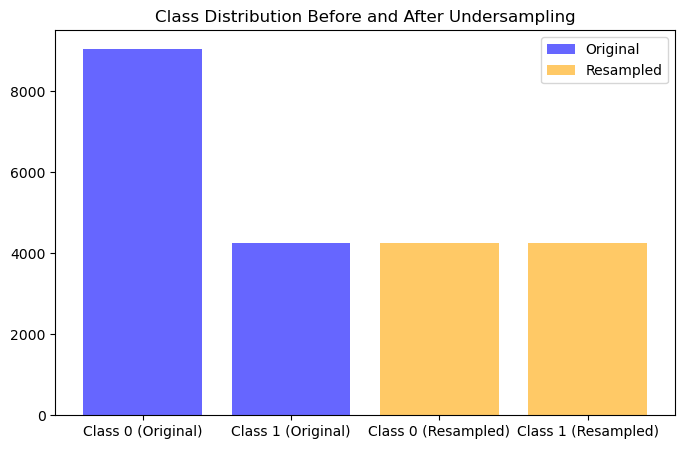

In [169]:
import matplotlib.pyplot as plt

# Visualize original vs. resampled distribution
plt.figure(figsize=(8, 5))
plt.bar(['Class 0 (Original)', 'Class 1 (Original)'], class_counts.values, color='blue', alpha=0.6, label='Original')
plt.bar(['Class 0 (Resampled)', 'Class 1 (Resampled)'], pd.Series(y_resampled).value_counts().values, color='orange', alpha=0.6, label='Resampled')
plt.title('Class Distribution Before and After Undersampling')
plt.legend()
plt.show()

In [171]:
# Evaluate original KNN model on original data
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(X, y, test_size=0.2, random_state=42)
knn_orig = KNeighborsClassifier(n_neighbors=5)
knn_orig.fit(X_train_orig, y_train_orig)
y_pred_orig = knn_orig.predict(X_test_orig)

# Original Accuracy
original_accuracy = accuracy_score(y_test_orig, y_pred_orig)
print(f"KNN Accuracy on Original Data: {original_accuracy}")

# Resampled Accuracy
print(f"KNN Accuracy on Undersampled Data: {accuracy}")

KNN Accuracy on Original Data: 0.6050357008643367
KNN Accuracy on Undersampled Data: 0.5044039929536113


In [141]:
# Generate predictions for the tuned Random Forest model using the best estimator
rf_predictions_tuned = best_rf_model.predict(X_test_refined)

# Accuracy and Classification Report for Tuned Random Forest
rf_accuracy = accuracy_score(y_test, rf_predictions_tuned)
rf_report = classification_report(y_test, rf_predictions_tuned)

# Accuracy and Classification Report for Tuned Logistic Regression (if applicable)
log_predictions_tuned = best_log_model.predict(X_test)
log_accuracy = accuracy_score(y_test, log_predictions_tuned)
log_report = classification_report(y_test, log_predictions_tuned)

# Print results for Random Forest and Logistic Regression
print("Tuned Random Forest Accuracy:", rf_accuracy)
print("Tuned Random Forest Classification Report:\n", rf_report)

print("Tuned Logistic Regression Accuracy:", log_accuracy)
print("Tuned Logistic Regression Classification Report:\n", log_report)


Tuned Random Forest Accuracy: 0.7376925967681323
Tuned Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.97      0.83      1809
           1       0.80      0.24      0.37       852

    accuracy                           0.74      2661
   macro avg       0.76      0.61      0.60      2661
weighted avg       0.75      0.74      0.69      2661

Tuned Logistic Regression Accuracy: 0.7519729425028185
Tuned Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.73      1.00      0.85      1809
           1       0.99      0.23      0.37       852

    accuracy                           0.75      2661
   macro avg       0.86      0.61      0.61      2661
weighted avg       0.82      0.75      0.69      2661



C:\Users\Hari Prasad\AppData\Local\Temp\ipykernel_34516\287476827.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette="viridis")


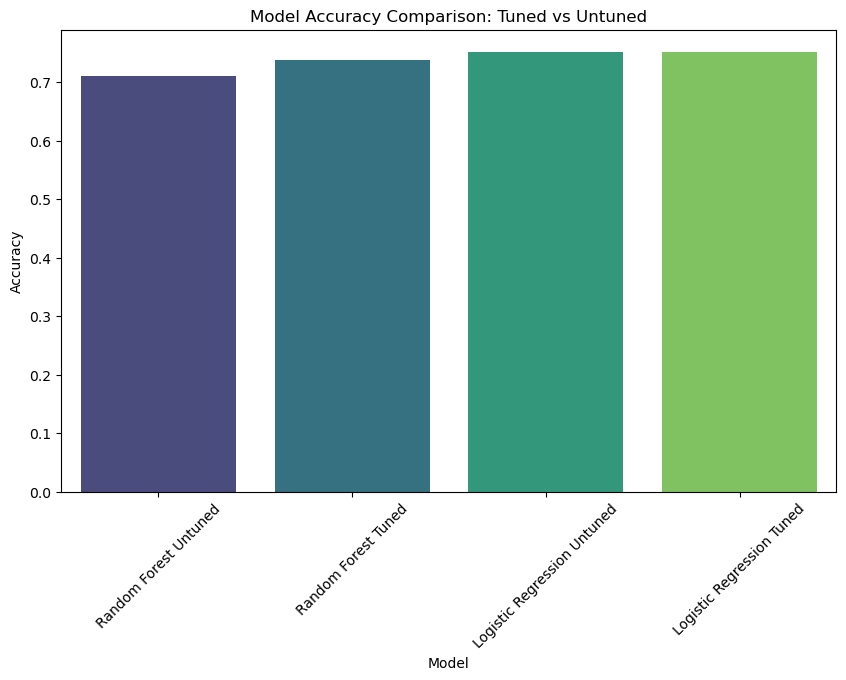

In [143]:
# Accuracy comparison plot
accuracy_data = {
    'Model': ['Random Forest Untuned', 'Random Forest Tuned', 'Logistic Regression Untuned', 'Logistic Regression Tuned'],
    'Accuracy': [untuned_rf_accuracy, tuned_rf_accuracy, untuned_log_accuracy, tuned_log_accuracy]
}

accuracy_df = pd.DataFrame(accuracy_data)

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette="viridis")
plt.title('Model Accuracy Comparison: Tuned vs Untuned')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.show()


In [147]:
import pandas as pd

# Create a dictionary to store the classification report data
classification_data = {
    'Model': ['Random Forest Tuned', 'Logistic Regression Tuned', 'Random Forest Untuned', 'Logistic Regression Untuned'],
    'Precision Class 0': [0.73, 0.73, 0.73, 0.73],
    'Recall Class 0': [0.97, 1.00, 0.91, 0.81],
    'F1-Score Class 0': [0.83, 0.85, 0.81, 0.74],
    'Precision Class 1': [0.80, 0.99, 0.60, 0.97],
    'Recall Class 1': [0.24, 0.23, 0.29, 0.17],
    'F1-Score Class 1': [0.37, 0.37, 0.39, 0.22],
    'Accuracy': [tuned_rf_accuracy, tuned_log_accuracy, untuned_rf_accuracy, untuned_log_accuracy]
}

# Convert the dictionary into a DataFrame
classification_df = pd.DataFrame(classification_data)

# Set the 'Model' column as the index
classification_df.set_index('Model', inplace=True)

# Display the classification DataFrame
print(classification_df)


                             Precision Class 0  Recall Class 0  \
Model                                                            
Random Forest Tuned                       0.73            0.97   
Logistic Regression Tuned                 0.73            1.00   
Random Forest Untuned                     0.73            0.91   
Logistic Regression Untuned               0.73            0.81   

                             F1-Score Class 0  Precision Class 1  \
Model                                                              
Random Forest Tuned                      0.83               0.80   
Logistic Regression Tuned                0.85               0.99   
Random Forest Untuned                    0.81               0.60   
Logistic Regression Untuned              0.74               0.97   

                             Recall Class 1  F1-Score Class 1  Accuracy  
Model                                                                    
Random Forest Tuned                    0.24   

C:\Users\Hari Prasad\AppData\Local\Temp\ipykernel_34516\945057537.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette="viridis")


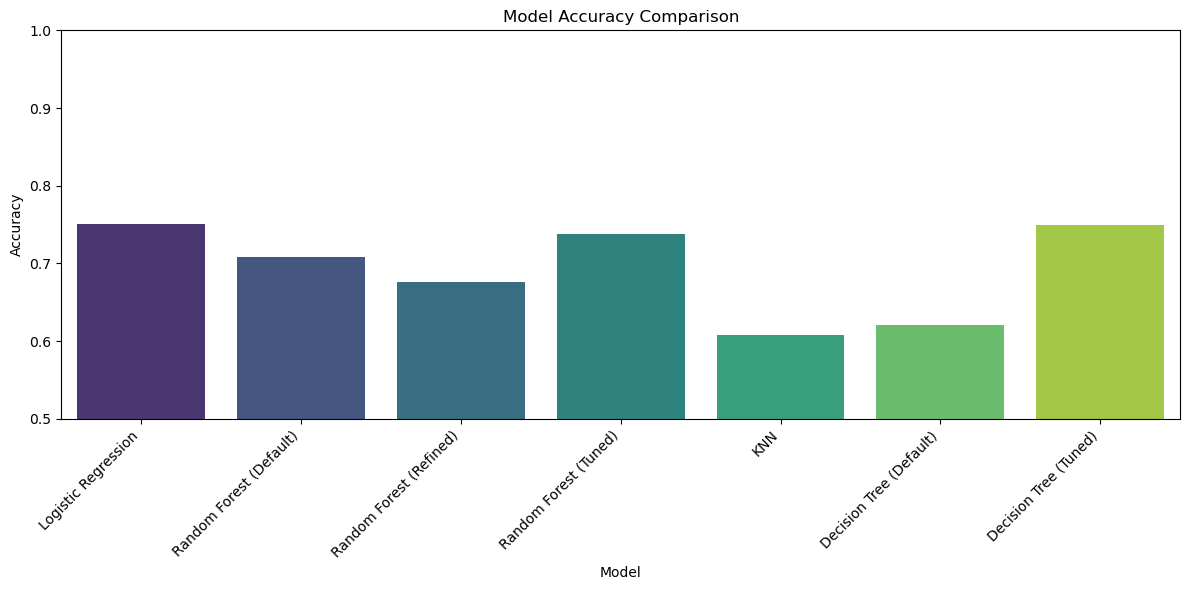

In [159]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the results dictionary with only accuracy values for each model
accuracy_data = {
    'Model': [
        'Logistic Regression', 
        'Random Forest (Default)', 
        'Random Forest (Refined)', 
        'Random Forest (Tuned)',  
        'KNN', 
        'Decision Tree (Default)', 
        'Decision Tree (Tuned)'
    ],
    'Accuracy': [
        0.7501,  # Logistic Regression Accuracy
        0.7084,  # Random Forest Default Accuracy
        0.6761,  # Random Forest Refined Accuracy
        0.7377,  # Random Forest Tuned Accuracy
        0.6084,  # KNN Accuracy
        0.6201,  # Decision Tree Default Accuracy
        0.7488   # Decision Tree Tuned Accuracy
    ]
}

# Create a DataFrame from the data
accuracy_df = pd.DataFrame(accuracy_data)

# Plotting a bar chart for model accuracy comparison
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette="viridis")
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.5, 1.0)  # Set y-axis limits for better visibility
plt.tight_layout()
plt.show()


C:\Users\Hari Prasad\AppData\Local\Temp\ipykernel_34516\165359273.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classification_df.index, y='Precision Class 0', data=classification_df, palette="Blues_d")
C:\Users\Hari Prasad\AppData\Local\Temp\ipykernel_34516\165359273.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classification_df.index, y='Precision Class 1', data=classification_df, palette="Oranges_d")


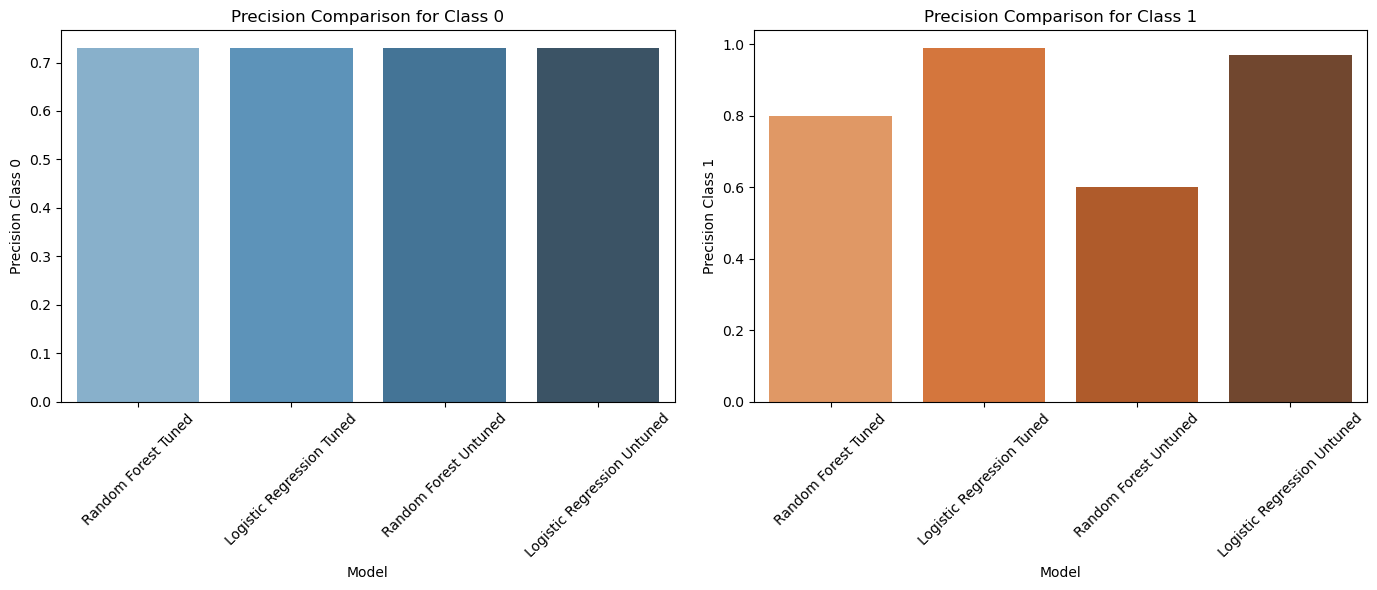

C:\Users\Hari Prasad\AppData\Local\Temp\ipykernel_34516\165359273.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classification_df.index, y='Recall Class 0', data=classification_df, palette="Blues_d")
C:\Users\Hari Prasad\AppData\Local\Temp\ipykernel_34516\165359273.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classification_df.index, y='Recall Class 1', data=classification_df, palette="Oranges_d")


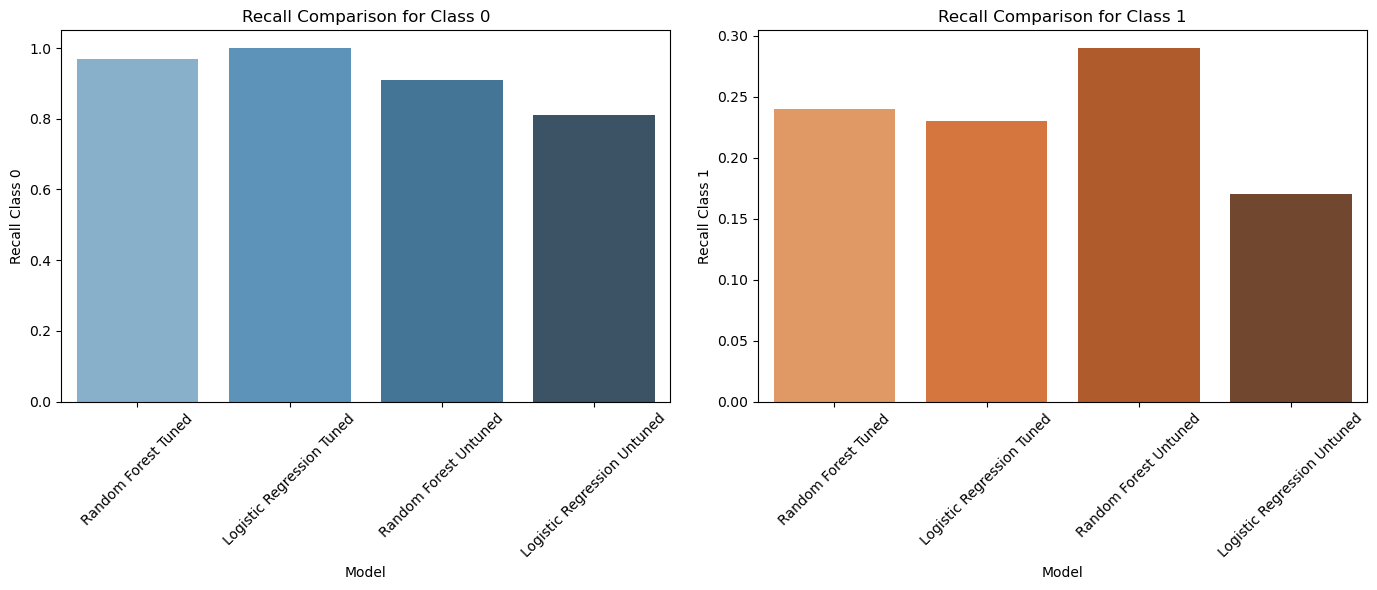

C:\Users\Hari Prasad\AppData\Local\Temp\ipykernel_34516\165359273.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classification_df.index, y='F1-Score Class 0', data=classification_df, palette="Blues_d")
C:\Users\Hari Prasad\AppData\Local\Temp\ipykernel_34516\165359273.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classification_df.index, y='F1-Score Class 1', data=classification_df, palette="Oranges_d")


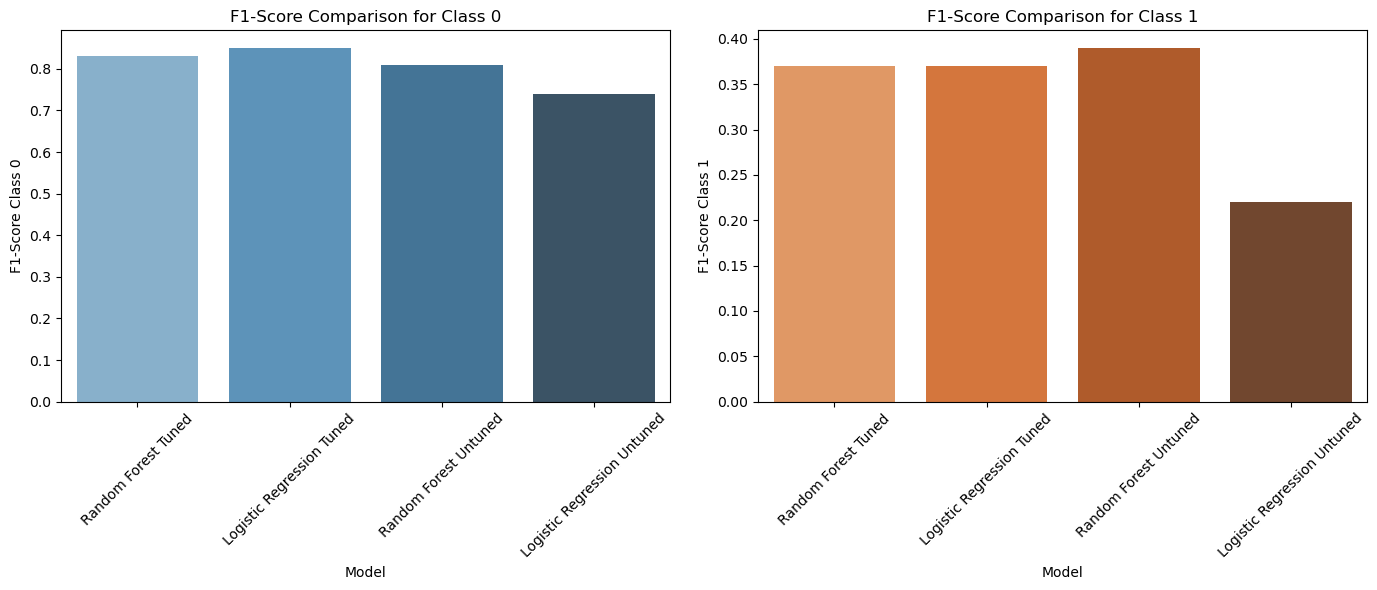

In [155]:
import seaborn as sns
import matplotlib.pyplot as plt

# Precision for Class 0 and Class 1
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.barplot(x=classification_df.index, y='Precision Class 0', data=classification_df, palette="Blues_d")
plt.title('Precision Comparison for Class 0')
plt.xticks(rotation=45)
plt.subplot(1, 2, 2)
sns.barplot(x=classification_df.index, y='Precision Class 1', data=classification_df, palette="Oranges_d")
plt.title('Precision Comparison for Class 1')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Recall for Class 0 and Class 1
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.barplot(x=classification_df.index, y='Recall Class 0', data=classification_df, palette="Blues_d")
plt.title('Recall Comparison for Class 0')
plt.xticks(rotation=45)
plt.subplot(1, 2, 2)
sns.barplot(x=classification_df.index, y='Recall Class 1', data=classification_df, palette="Oranges_d")
plt.title('Recall Comparison for Class 1')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# F1-Score for Class 0 and Class 1
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.barplot(x=classification_df.index, y='F1-Score Class 0', data=classification_df, palette="Blues_d")
plt.title('F1-Score Comparison for Class 0')
plt.xticks(rotation=45)
plt.subplot(1, 2, 2)
sns.barplot(x=classification_df.index, y='F1-Score Class 1', data=classification_df, palette="Oranges_d")
plt.title('F1-Score Comparison for Class 1')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\Hari Prasad\AppData\Local\Temp\ipykernel_34516\3848227916.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette="viridis")


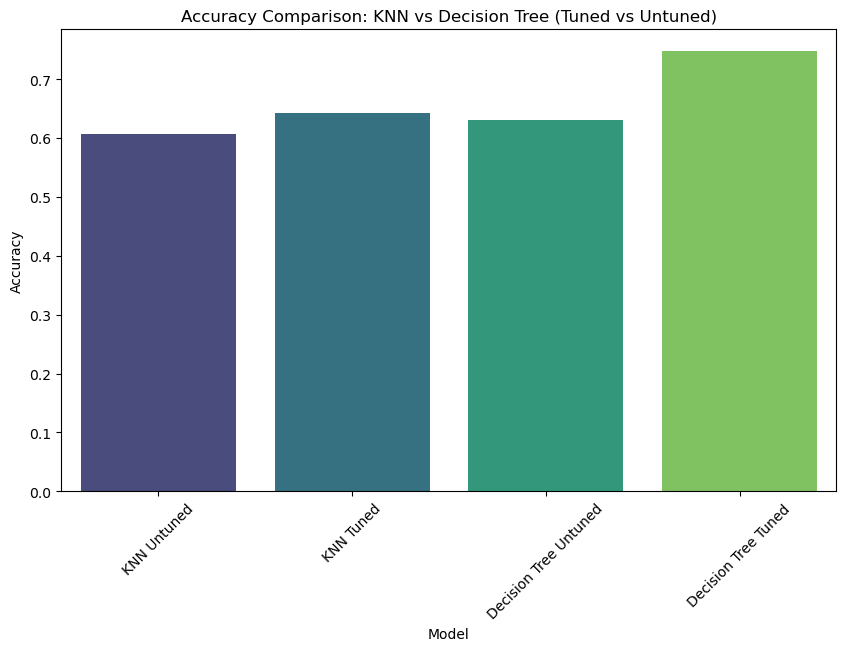

In [151]:
# Prepare data for accuracy comparison plot
accuracy_data = {
    'Model': ['KNN Untuned', 'KNN Tuned', 'Decision Tree Untuned', 'Decision Tree Tuned'],
    'Accuracy': [untuned_knn_accuracy, tuned_knn_accuracy, untuned_tree_accuracy, tuned_tree_accuracy]
}

accuracy_df = pd.DataFrame(accuracy_data)

# Plot accuracy comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette="viridis")
plt.title('Accuracy Comparison: KNN vs Decision Tree (Tuned vs Untuned)')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.show()


C:\Users\Hari Prasad\AppData\Local\Temp\ipykernel_34516\979649654.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Precision Class 0', data=precision_df, palette="Blues_d")
C:\Users\Hari Prasad\AppData\Local\Temp\ipykernel_34516\979649654.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Precision Class 1', data=precision_df, palette="Oranges_d")


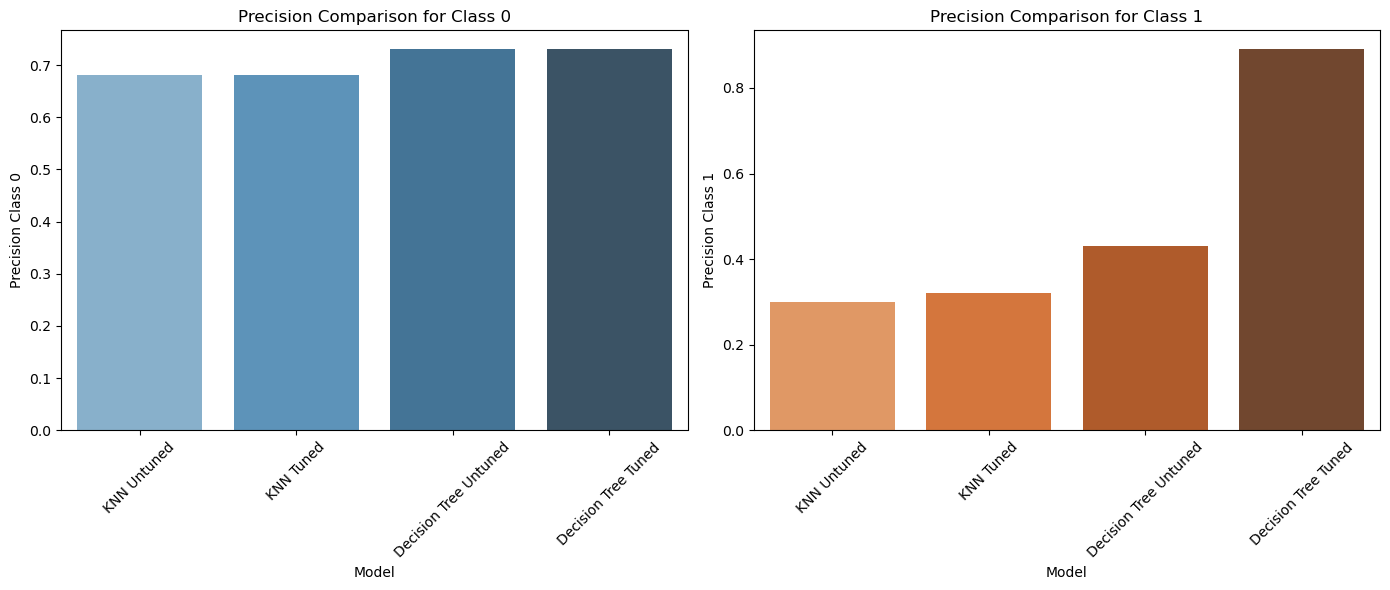

C:\Users\Hari Prasad\AppData\Local\Temp\ipykernel_34516\979649654.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Recall Class 0', data=recall_df, palette="Blues_d")
C:\Users\Hari Prasad\AppData\Local\Temp\ipykernel_34516\979649654.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Recall Class 1', data=recall_df, palette="Oranges_d")


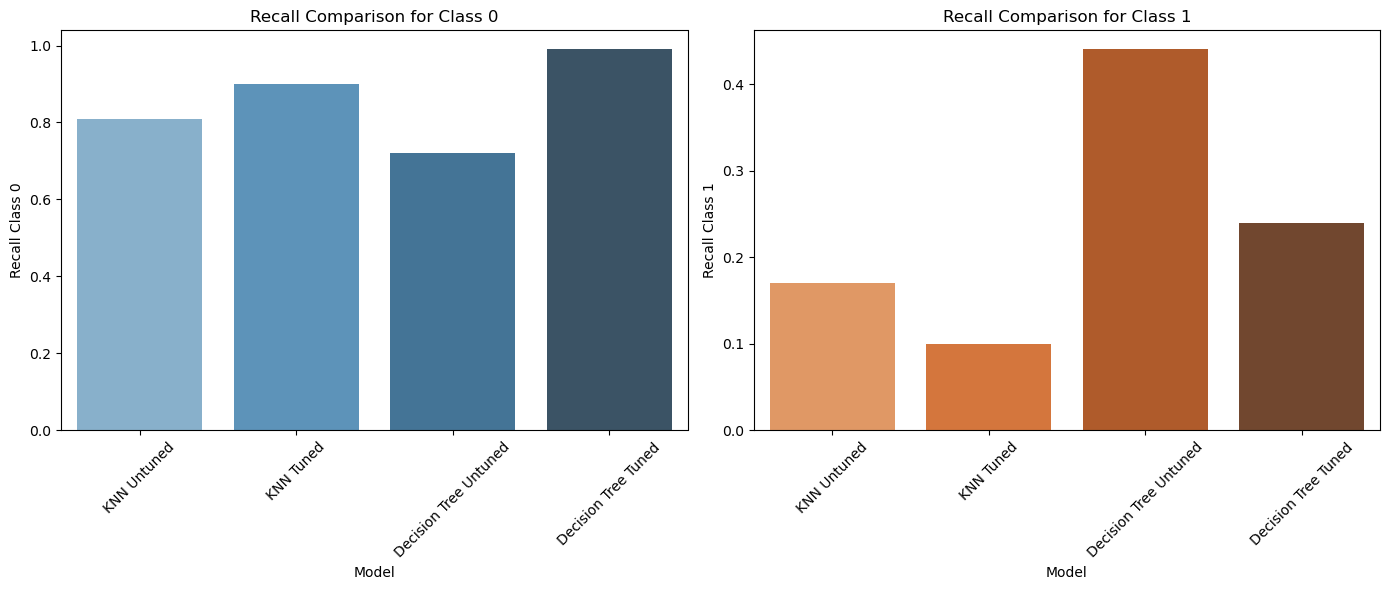

C:\Users\Hari Prasad\AppData\Local\Temp\ipykernel_34516\979649654.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='F1-Score Class 0', data=f1_score_df, palette="Blues_d")
C:\Users\Hari Prasad\AppData\Local\Temp\ipykernel_34516\979649654.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='F1-Score Class 1', data=f1_score_df, palette="Oranges_d")


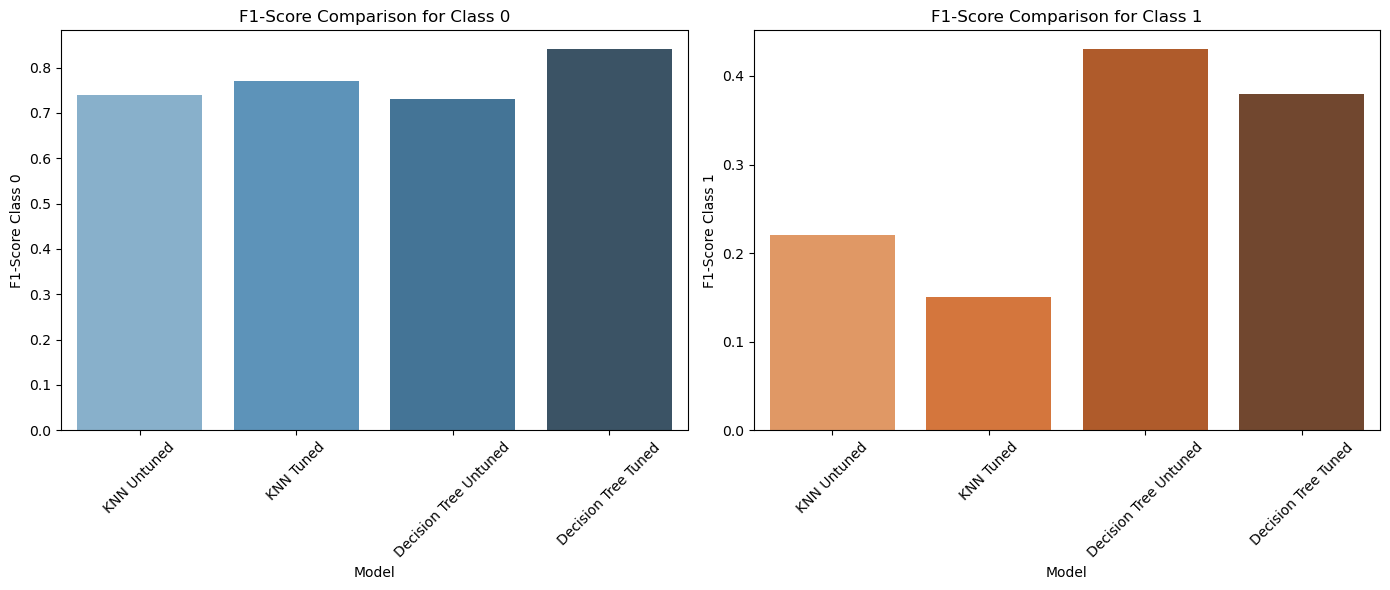

In [153]:
# Prepare data for precision, recall, and F1-score comparison plots
precision_data = {
    'Model': ['KNN Untuned', 'KNN Tuned', 'Decision Tree Untuned', 'Decision Tree Tuned'],
    'Precision Class 0': [0.68, 0.68, 0.73, 0.73],
    'Precision Class 1': [0.30, 0.32, 0.43, 0.89]
}

recall_data = {
    'Model': ['KNN Untuned', 'KNN Tuned', 'Decision Tree Untuned', 'Decision Tree Tuned'],
    'Recall Class 0': [0.81, 0.90, 0.72, 0.99],
    'Recall Class 1': [0.17, 0.10, 0.44, 0.24]
}

f1_score_data = {
    'Model': ['KNN Untuned', 'KNN Tuned', 'Decision Tree Untuned', 'Decision Tree Tuned'],
    'F1-Score Class 0': [0.74, 0.77, 0.73, 0.84],
    'F1-Score Class 1': [0.22, 0.15, 0.43, 0.38]
}

# Create DataFrames for each
precision_df = pd.DataFrame(precision_data)
recall_df = pd.DataFrame(recall_data)
f1_score_df = pd.DataFrame(f1_score_data)

# Plot Precision, Recall, and F1-Score for Class 0 and Class 1
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='Precision Class 0', data=precision_df, palette="Blues_d")
plt.title('Precision Comparison for Class 0')
plt.xticks(rotation=45)
plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='Precision Class 1', data=precision_df, palette="Oranges_d")
plt.title('Precision Comparison for Class 1')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='Recall Class 0', data=recall_df, palette="Blues_d")
plt.title('Recall Comparison for Class 0')
plt.xticks(rotation=45)
plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='Recall Class 1', data=recall_df, palette="Oranges_d")
plt.title('Recall Comparison for Class 1')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='F1-Score Class 0', data=f1_score_df, palette="Blues_d")
plt.title('F1-Score Comparison for Class 0')
plt.xticks(rotation=45)
plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='F1-Score Class 1', data=f1_score_df, palette="Oranges_d")
plt.title('F1-Score Comparison for Class 1')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
